## import packages

In [6]:
# !pip install NumPy==2.4

In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import numpy as np
import scipy.io
import os
import numpy as np
from scipy.stats import pearsonr
import lime 
import lime.lime_tabular
import numpy as np 
import shap

import pandas as pd
import joblib
import numpy as np
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [2]:
import warnings
warnings.filterwarnings("ignore")

## Load dataset

In [3]:
# Define the base path (adjust path if needed)
base_dir = os.path.join(os.path.expanduser("~"), "Desktop", "TEAM - Dataset", "data")

# Load only the first dataset
data = scipy.io.loadmat(os.path.join(base_dir, "1", "data.mat"))

# Extract variabl
X, y = data['X'], data['y']

# Add name to the features
X = pd.DataFrame(
    X,
    columns=[f"feature_{i}" for i in range(X.shape[1])],
    index=range(len(X))
)

print(f"Loaded successfully. Features shape: {X.shape}, Labels shape: {y.shape}")

Loaded successfully. Features shape: (198, 33), Labels shape: (198, 1)


In [6]:
num_rows, num_features = X.shape[0], X.shape[1]

In [9]:
num_rows, num_features

(198, 33)

In [38]:
X.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32
0,-0.456501,0.192201,1.238630,0.123621,0.121991,-0.622197,-0.782558,-0.675092,-0.478962,-0.227943,...,-0.022420,0.052971,-1.109830,-1.052060,-0.706613,-1.367350,-0.741131,-0.458065,1.110710,0.340583
1,0.414001,0.182712,-2.767610,0.371477,0.087915,1.255230,2.704580,2.038440,1.780710,1.791240,...,1.531630,1.047840,0.830725,1.832700,1.585110,1.917250,1.818710,1.325900,0.078704,-0.210660
2,2.009920,1.251770,-1.125100,1.058930,1.144290,-1.143660,-0.475930,-0.435621,-0.146874,1.477790,...,0.649039,0.928387,-1.141650,-0.123208,-0.548801,0.540553,1.463470,-0.007469,-0.179299,-0.578156
3,2.213040,-1.895300,-0.441108,-1.743250,-1.658220,3.179780,2.830840,1.206670,0.543867,2.440000,...,-1.435600,-1.428750,2.993970,3.056740,1.441130,1.742400,4.528900,3.881160,-0.437302,-0.578156
4,-0.572568,0.910175,-1.846320,0.946689,0.928467,-0.190172,-0.197360,0.591695,0.517300,-0.432048,...,0.410221,0.290170,-0.296345,-0.976439,-0.211291,-0.360278,-1.157570,-0.663525,0.336707,-0.578156


### Train-Test split

In [10]:
# Create the training and testing sets explicitly 
X_train, X_test, y_train, y_test = train_test_split(X, y.ravel(), test_size = 0.2, random_state = 42)

In [11]:
from sklearn.model_selection import train_test_split

def train_test_split_custom(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y.ravel(),
        test_size=0.2,
        random_state=42
    )
    return X_train, X_test, y_train, y_test

## Train models

### Random Forest Model

In [12]:
def train_rf_model(X_train, y_train):
    RF_model = RandomForestClassifier(n_estimators=100, random_state=42)
    RF_model.fit(X_train, y_train)
    return RF_model

In [13]:
rf_model_dataset1 = train_rf_model(X_train, y_train)

In [14]:
# Create models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save the model
joblib.dump(rf_model_dataset1, "results/rf_model_dataset1.pkl")

['results/rf_model_dataset1.pkl']

#### Load the trained model

In [15]:
rf_model_dataset1 = joblib.load("results/rf_model_dataset1.pkl")

In [18]:
# Get predicted probabilities for the positive class (class = 1)
y_pred_proba = rf_model_dataset1.predict_proba(X_test)[:, 1]

# Compute AUC
baseline_rf_auc = roc_auc_score(y_test, y_pred_proba)

print(f"AUC: {baseline_rf_auc:.4f}")

AUC: 0.5781


In [19]:
# prediction function
def predict_model(model, X, y):
    # Get predicted probabilities for the positive class (class = 1)
    y_pred_proba_lr = model.predict_proba(X)[:, 1]
    
    # Compute AUC
    auc_score_lr = roc_auc_score(y, y_pred_proba_lr)
    
    return round(auc_score_lr, 4)

### SHAP for the RF Model

In [20]:
# Initialize explainer (TreeExplainer is used automatically for RF)
explainer = shap.Explainer(rf_model_dataset1, X_train)

shap_values = explainer(X, check_additivity=False)

Background dataset has 158 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=158 when initializing the masker.


In [21]:
def get_rf_shap_values(rf_model, X_train, X):
    # Create explainer
    explainer = shap.Explainer(
        rf_model,
        X_train,
    )
    
    # Compute SHAP values
    shap_values = explainer(X, check_additivity=False)
    shap_class1 = shap_values[:, :, 1]
    
    return shap_class1.values

In [22]:
rf_shap_values = get_rf_shap_values(rf_model_dataset1, X_train, X)

Background dataset has 158 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=158 when initializing the masker.


In [23]:
rf_shap_values

array([[ 0.0077131 , -0.01279   , -0.01037952, ...,  0.00354286,
         0.0138131 ,  0.02832619],
       [-0.04265964, -0.00118   ,  0.02465512, ...,  0.00551143,
        -0.00565298, -0.01582619],
       [-0.06508631, -0.01178809, -0.0018831 , ...,  0.00713   ,
        -0.00638155, -0.03170952],
       ...,
       [ 0.01850107, -0.01006798, -0.00801393, ..., -0.01662214,
         0.00483857, -0.03666333],
       [ 0.16283571,  0.01222714,  0.00060619, ...,  0.01245286,
         0.0372994 , -0.01950607],
       [ 0.04540976, -0.00918179, -0.00643464, ...,  0.0009    ,
         0.0105881 , -0.0394769 ]])

In [24]:
np.save("results/rf_shap_values.npy", rf_shap_values)

In [25]:
# rf_shap_values = np.load("results/rf_shap_values.npy")

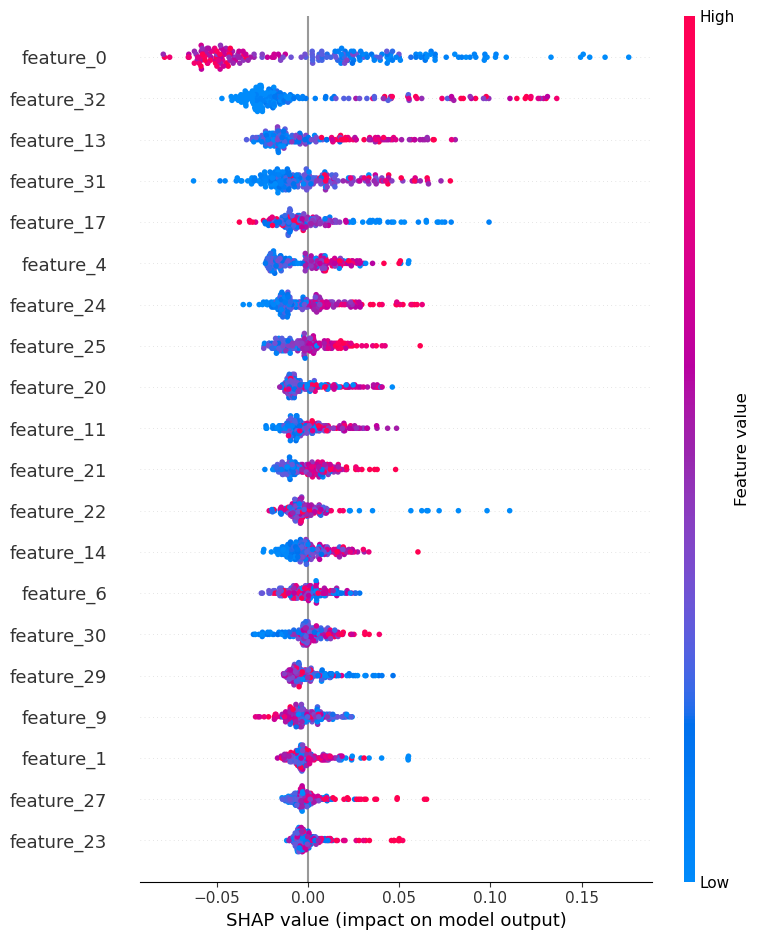

In [26]:
shap.summary_plot(rf_shap_values, X)

### LIME for the RF Model

In [27]:
def get_lime_values(model, X_train, X):
    explainer = LimeTabularExplainer(
        training_data=X_train.values,
        feature_names=X_train.columns,
        class_names=["0", "1"],
        mode="classification"
    )
    
    lime_matrix = np.zeros((X.shape[0], X.shape[1]))

    for i in range(X.shape[0]):
        exp = explainer.explain_instance(
            data_row=X.values[i],
            predict_fn=model.predict_proba
        )

        # THIS IS THE FIX ↓
        for idx, weight in exp.as_map()[1]:  # class 1
            lime_matrix[i, idx] = weight

    return lime_matrix

In [28]:
rf_lime_values = get_lime_values(rf_model_dataset1, X_train, X)

In [29]:
rf_lime_values

array([[ 0.02828019, -0.01050777,  0.        , ...,  0.        ,
         0.04363278,  0.06619852],
       [-0.04480726,  0.        ,  0.        , ...,  0.01650968,
         0.        , -0.02697213],
       [-0.0662605 ,  0.        ,  0.        , ...,  0.        ,
         0.        , -0.02728031],
       ...,
       [ 0.07182222,  0.        ,  0.        , ..., -0.0172306 ,
         0.04504761, -0.02662314],
       [ 0.0750785 ,  0.        ,  0.        , ...,  0.        ,
         0.        , -0.02482778],
       [ 0.07572867, -0.00640587,  0.        , ...,  0.        ,
         0.        , -0.02962309]])

In [30]:
np.save("results/rf_lime_values.npy", rf_lime_values)

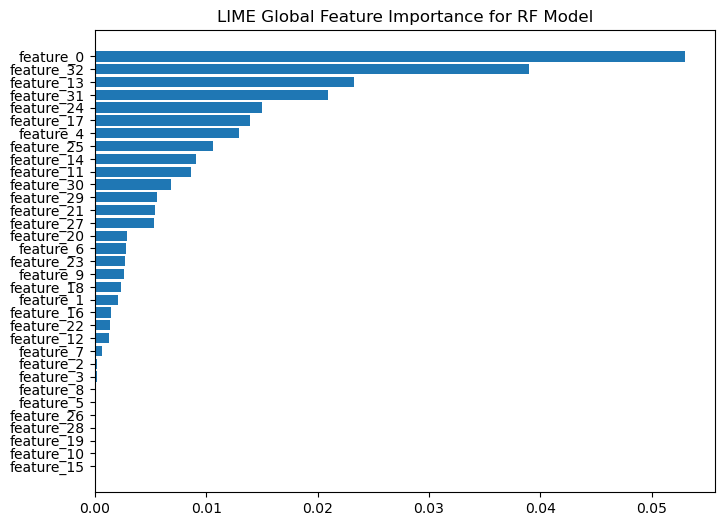

In [31]:
lime_importance = np.abs(rf_lime_values).mean(axis=0)

lime_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": lime_importance
}).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(lime_importance_df["feature"], lime_importance_df["importance"])
plt.title("LIME Global Feature Importance for RF Model")
plt.show()

### Logistic regression model

In [32]:
def train_lr_model(X_train, y_train):
    LR_model = LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        random_state=42
    )
    LR_model.fit(X_train, y_train)
    return LR_model

In [33]:
lr_model_dataset1 = train_lr_model(X_train, y_train)

In [34]:
# Save the model
joblib.dump(lr_model_dataset1, "results/lr_model_dataset1.pkl")

['results/lr_model_dataset1.pkl']

In [35]:
# load the saved model
lr_model_dataset1 = joblib.load("results/lr_model_dataset1.pkl")

In [36]:
# Get predicted probabilities for the positive class (class = 1)
y_pred_proba_lr = lr_model_dataset1.predict_proba(X_test)[:, 1]

# Compute AUC
baseline_lr_auc = roc_auc_score(y_test, y_pred_proba_lr)

print(f"AUC: {baseline_lr_auc:.4f}")

AUC: 0.7656


### SHAP for the LR Model

In [37]:
def get_lr_shap_values(model, X_train, X):
    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X, check_additivity=False)

    # Handle both cases automatically
    if len(shap_values.shape) == 3:
        # Tree models (RF, XGBoost, etc.)
        return shap_values[:, :, 1].values
    else:
        # Linear models (Logistic Regression)
        return shap_values.values

In [38]:
lr_shap_values = get_lr_shap_values(lr_model_dataset1, X_train, X)

Background dataset has 158 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=158 when initializing the masker.


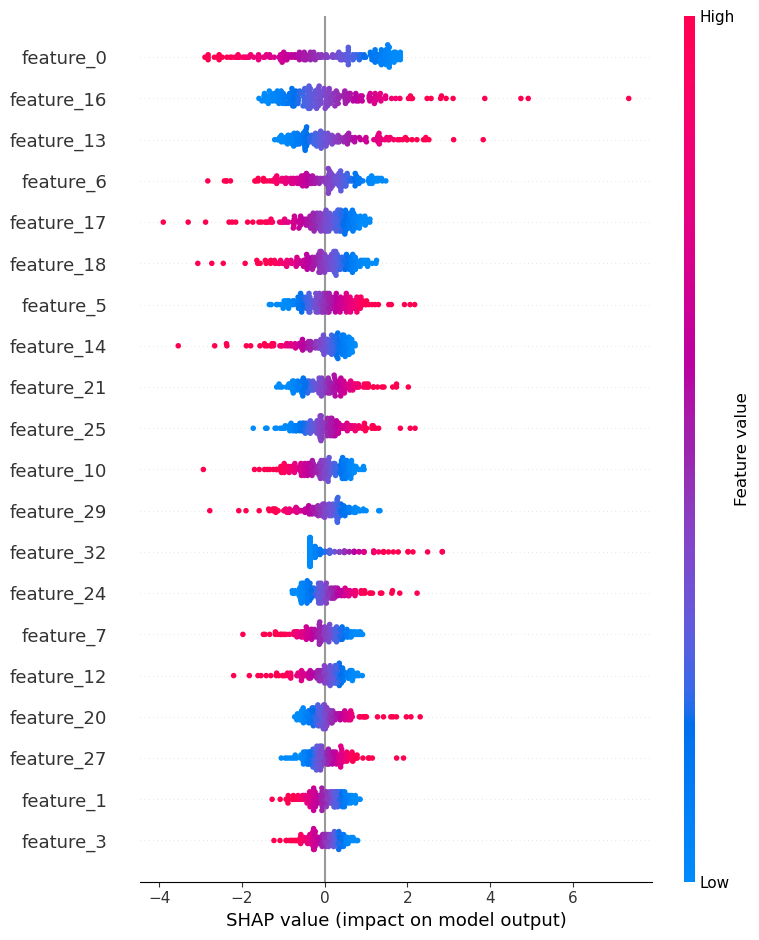

In [39]:
shap.summary_plot(lr_shap_values, X)

In [40]:
lr_shap_values.shape

(198, 33)

In [41]:
# Save shap values for the LR model
np.save("results/lr_shap_values.npy", lr_shap_values)

### LIME for the LR Model

In [42]:
lr_lime_values = get_lime_values(lr_model_dataset1, X_train, X)

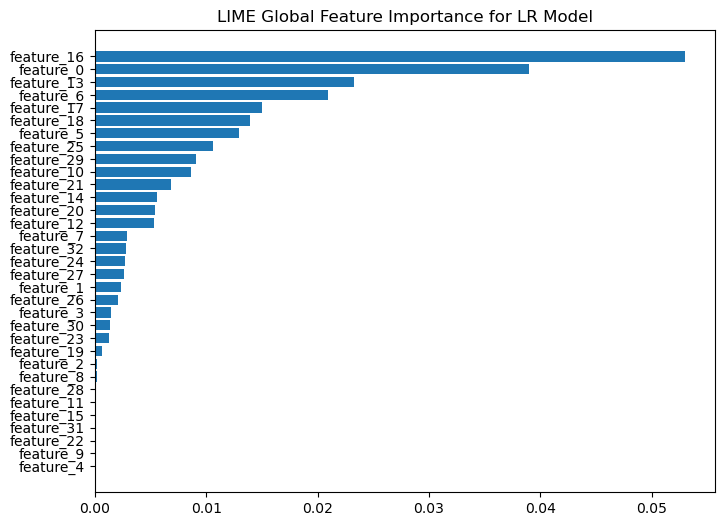

In [43]:
lr_lime_importance = np.abs(lr_lime_values).mean(axis=0)

lr_lime_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": lr_lime_importance
}).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(lr_lime_importance_df["feature"], lime_importance_df["importance"])
plt.title("LIME Global Feature Importance for LR Model")
plt.show()

In [44]:
lr_lime_values.shape

(198, 33)

In [45]:
# Save shap values for the LR model
np.save("results/lr_lime_values.npy", lr_lime_values)

### Correlation Anaysis

In [46]:
def get_person_corr(shap_values, lime_values):
    instance_corrs = []
    p_values = []
    
    for i in range(shap_values.shape[0]):
        shap_i = shap_values[i]
        lime_i = lime_values[i]
        
        corr, p = pearsonr(shap_i, lime_i)
        
        instance_corrs.append(corr)
        p_values.append(p)
    
    instance_corrs = np.array(instance_corrs)
    p_values = np.array(p_values)
    return instance_corrs, p_values

In [47]:
# Corr RF_LIME vs  LR_LIME
# Corr RF_Shap Vs LR_shap
# Corr RF_lime vs RF_shap
# Corr LR_lime Vs LR_shap

In [48]:
rf_lime_lr_lime, _ = get_person_corr(rf_lime_values, lr_lime_values)
rf_shap_lr_shap, _ = get_person_corr(rf_shap_values, lr_shap_values)
rf_lim_rf_shap, _ = get_person_corr(rf_lime_values, rf_shap_values)
lr_lim_lr_shap, _ = get_person_corr(lr_lime_values, lr_shap_values)

In [49]:
# Save the results in a dataframe
corr_results_df = pd.DataFrame(index=X.index)

corr_results_df["rf_lime_lr_lime"] = rf_lime_lr_lime
corr_results_df["rf_shap_lr_shap"] = rf_shap_lr_shap
corr_results_df["rf_lime_rf_shap"] = rf_lim_rf_shap
corr_results_df["lr_lime_lr_shap"] = lr_lim_lr_shap

In [50]:
corr_results_df.shape

(198, 4)

In [51]:
corr_results_df.head()

,rf_lime_lr_lime,rf_shap_lr_shap,rf_lime_rf_shap,lr_lime_lr_shap
0,0.397610,0.328381,0.793763,0.881044
1,0.179373,0.401174,0.651872,0.752222
2,0.656669,0.640063,0.838648,0.871703
3,0.502530,0.559109,0.731817,0.833765
4,0.444309,0.504218,0.712724,0.784585


In [52]:
corr_results_df["mean_corr"] = corr_results_df.mean(axis=1)

In [53]:
corr_results_df.head()

,rf_lime_lr_lime,rf_shap_lr_shap,rf_lime_rf_shap,lr_lime_lr_shap,mean_corr
0,0.397610,0.328381,0.793763,0.881044,0.600199
1,0.179373,0.401174,0.651872,0.752222,0.496160
2,0.656669,0.640063,0.838648,0.871703,0.751771
3,0.502530,0.559109,0.731817,0.833765,0.656805
4,0.444309,0.504218,0.712724,0.784585,0.611459


### Plot the distribution for mean correlation

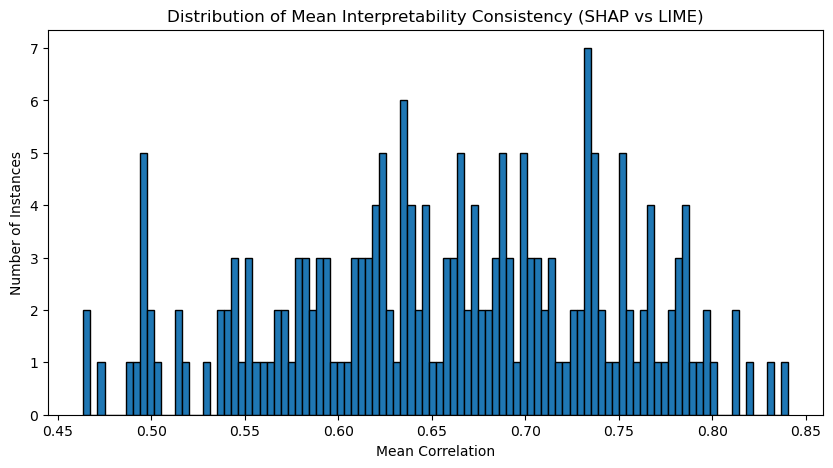

In [54]:
plt.figure(figsize=(10,5))

plt.hist(
    corr_results_df["mean_corr"],
    bins=100,
    edgecolor="black"
)

plt.title("Distribution of Mean Interpretability Consistency (SHAP vs LIME)")
plt.xlabel("Mean Correlation")
plt.ylabel("Number of Instances")

plt.show()

### Get Stats for the mean correlation

In [55]:
corr_results_df["mean_corr"].describe()

count    198.000000
mean       0.659398
std        0.087062
min        0.463737
25%        0.596022
50%        0.664736
75%        0.731579
max        0.840519
Name: mean_corr, dtype: float64

In [56]:
q25 = round(corr_results_df["mean_corr"].quantile(0.25), 4)
q75 = round(corr_results_df["mean_corr"].quantile(0.75), 4)

print("20th percentile:", q25)
print("80th percentile:", q75)

20th percentile: 0.596
80th percentile: 0.7316


### Split the data based on the correlation value

In [57]:
corr_results_df = corr_results_df.sort_index()
X = X.sort_index()

In [58]:
X_mean_corr = X.copy()
X_mean_corr["mean_corr"] = corr_results_df["mean_corr"]

In [59]:
X_mean_corr.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,mean_corr
0,-0.456501,0.192201,1.238630,0.123621,0.121991,-0.622197,-0.782558,-0.675092,-0.478962,-0.227943,...,0.052971,-1.109830,-1.052060,-0.706613,-1.367350,-0.741131,-0.458065,1.110710,0.340583,0.600199
1,0.414001,0.182712,-2.767610,0.371477,0.087915,1.255230,2.704580,2.038440,1.780710,1.791240,...,1.047840,0.830725,1.832700,1.585110,1.917250,1.818710,1.325900,0.078704,-0.210660,0.496160
2,2.009920,1.251770,-1.125100,1.058930,1.144290,-1.143660,-0.475930,-0.435621,-0.146874,1.477790,...,0.928387,-1.141650,-0.123208,-0.548801,0.540553,1.463470,-0.007469,-0.179299,-0.578156,0.751771
3,2.213040,-1.895300,-0.441108,-1.743250,-1.658220,3.179780,2.830840,1.206670,0.543867,2.440000,...,-1.428750,2.993970,3.056740,1.441130,1.742400,4.528900,3.881160,-0.437302,-0.578156,0.656805
4,-0.572568,0.910175,-1.846320,0.946689,0.928467,-0.190172,-0.197360,0.591695,0.517300,-0.432048,...,0.290170,-0.296345,-0.976439,-0.211291,-0.360278,-1.157570,-0.663525,0.336707,-0.578156,0.611459


In [60]:
# Above 25th percentile
X_instances_mean_corr_above_25th = X_mean_corr[X_mean_corr["mean_corr"] > q25]
X_instances_mean_corr_above_25th = X_instances_mean_corr_above_25th.drop(columns="mean_corr")

# Below 75th percentile
X_instances_mean_corr_below_75th = X_mean_corr[X_mean_corr["mean_corr"] < q75]
X_instances_mean_corr_below_75th = X_instances_mean_corr_below_75th.drop(columns="mean_corr")

# Between 25th and 75th percentile
X_instances_mean_corr_between_25_75 = X_mean_corr[
    (X_mean_corr["mean_corr"] > q25) &
    (X_mean_corr["mean_corr"] < q75)
]
X_instances_mean_corr_between_25_75 = X_instances_mean_corr_between_25_75.drop(columns="mean_corr")

In [92]:
mc_above25th = X_instances_mean_corr_above_25th.shape[0]
mc_below75th = X_instances_mean_corr_below_75th.shape[0]
mc_between25_75th = X_instances_mean_corr_between_25_75.shape[0]

In [61]:
# Corrosponding y values for training
y_instances_mean_corr_above_25th = y[X_instances_mean_corr_above_25th.index]
y_instances_mean_corr_below_75th = y[X_instances_mean_corr_below_75th.index]
y_instances_mean_corr_between_25_75 = y[X_instances_mean_corr_between_25_75.index]

### Check the dimensions

In [62]:
print(X_instances_mean_corr_above_25th.shape, y_instances_mean_corr_above_25th.shape)
print(X_instances_mean_corr_below_75th.shape, y_instances_mean_corr_below_75th.shape)
print(X_instances_mean_corr_between_25_75.shape, y_instances_mean_corr_between_25_75.shape)

(148, 33) (148, 1)
(148, 33) (148, 1)
(98, 33) (98, 1)


### Retrain the RF Model for the New Subset data

In [63]:
def evaluate_data_subset(X, y, model_fn):
    # split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # train model (generalized)
    model = model_fn(X_train, y_train)
    
    # evaluate
    return predict_model(model, X_test, y_test)

### For Random Forest

In [65]:
# ============================================================
# Model Evaluation Across Interpretability Consistency Subsets
# ============================================================
# We evaluate model performance (AUC) on different subsets of the dataset
# defined by instance-level interpretability consistency.
#
# Consistency is measured using mean SHAP–LIME correlation.
# Higher values indicate stronger agreement between explanation methods.
# ============================================================


# ---------------------------
# High-consistency subset
# (above 25th percentile)
# ---------------------------
# Contains instances with relatively higher interpretability agreement.
rf_auc_above_25th = evaluate_data_subset(
    X_instances_mean_corr_above_25th,
    y_instances_mean_corr_above_25th,
    train_rf_model
)

print("AUC (Above 25th percentile consistency) for RF:", rf_auc_above_25th)


# ---------------------------
# Lower-consistency subset
# (below 75th percentile)
# ---------------------------
# Contains a broader set of instances including low and medium consistency.
rf_auc_below_75th = evaluate_data_subset(
    X_instances_mean_corr_below_75th,
    y_instances_mean_corr_below_75th,
    train_rf_model
)

print("AUC (Below 75th percentile consistency) for RF:", rf_auc_below_75th)


# ---------------------------
# Medium-consistency subset
# (between 25th and 75th percentile)
# ---------------------------
# Represents the central region of interpretability agreement distribution.
rf_auc_between_25_75 = evaluate_data_subset(
    X_instances_mean_corr_between_25_75,
    y_instances_mean_corr_between_25_75,
    train_rf_model
)

print("AUC (25th–75th percentile consistency) for RF:", rf_auc_between_25_75)

AUC (Above 25th percentile consistency) for RF: 0.6392
AUC (Below 75th percentile consistency) for RF: 0.5397
AUC (25th–75th percentile consistency) for RF: 0.4902


In [66]:
# ============================================================
# Model Evaluation Across Interpretability Consistency Subsets
# ============================================================
# We evaluate model performance (AUC) on different subsets of the dataset
# defined by instance-level interpretability consistency.
#
# Consistency is measured using mean SHAP–LIME correlation.
# Higher values indicate stronger agreement between explanation methods.
# ============================================================


# ---------------------------
# High-consistency subset
# (above 25th percentile)
# ---------------------------
# Contains instances with relatively higher interpretability agreement.
lr_auc_above_25th = evaluate_data_subset(
    X_instances_mean_corr_above_25th,
    y_instances_mean_corr_above_25th,
    train_lr_model
)

print("AUC (Above 25th percentile consistency) for LR:", lr_auc_above_25th)


# ---------------------------
# Lower-consistency subset
# (below 75th percentile)
# ---------------------------
# Contains a broader set of instances including low and medium consistency.
lr_auc_below_75th = evaluate_data_subset(
    X_instances_mean_corr_below_75th,
    y_instances_mean_corr_below_75th,
    train_lr_model
)

print("AUC (Below 75th percentile consistency) for LR:", lr_auc_below_75th)


# ---------------------------
# Medium-consistency subset
# (between 25th and 75th percentile)
# ---------------------------
# Represents the central region of interpretability agreement distribution.
lr_auc_between_25_75 = evaluate_data_subset(
    X_instances_mean_corr_between_25_75,
    y_instances_mean_corr_between_25_75,
    train_lr_model
)

print("AUC (25th–75th percentile consistency) for LR:", lr_auc_between_25_75)

AUC (Above 25th percentile consistency) for LR: 0.8125
AUC (Below 75th percentile consistency) for LR: 0.672
AUC (25th–75th percentile consistency) for LR: 0.3725


In [ ]:
mc_above25th = X_instances_mean_corr_above_25th.shape[0]
mc_below75th = X_instances_mean_corr_below_75th.shape[0]
mc_between25_75th = X_instances_mean_corr_between_25_75.shape[0]

### Analysis

In [102]:
results_dataset1_df = pd.DataFrame({
    "Model": [
        "Random Forest", "Random Forest", "Random Forest", "Random Forest",
        "Logistic Regression", "Logistic Regression", "Logistic Regression", "Logistic Regression"
    ],
    "Subset": [
        "Baseline (All data)",
        "Mean correlation > 25th percentile",
        "Mean correlation < 75th percentile",
        "Mean correlation 25th–75th percentile",
        
        "Baseline (All data)",
        "Mean correlation > 25th percentile",
        "Mean correlation < 75th percentile",
        "Mean correlation 25th–75th percentile"
    ],
    "AUC": [
        baseline_rf_auc, rf_auc_above_25th, rf_auc_below_75th, rf_auc_between_25_75,
        baseline_lr_auc, lr_auc_above_25th, lr_auc_below_75th, lr_auc_between_25_75
    ],
    "Num_rows": [
        num_rows, mc_above25th, mc_below75th, mc_between25_75th,
        num_rows, mc_above25th, mc_below75th, mc_between25_75th
    ],
    "Dataset": ["dataset1"] * 8
})

In [103]:
results_dataset1_df

,Model,Subset,AUC,Num_rows,Dataset
0,Random Forest,Baseline (All data),0.578125,198,dataset1
1,Random Forest,Mean correlation > 25th percentile,0.639200,148,dataset1
2,Random Forest,Mean correlation < 75th percentile,0.539700,148,dataset1
3,Random Forest,Mean correlation 25th–75th percentile,0.490200,98,dataset1
4,Logistic Regression,Baseline (All data),0.765625,198,dataset1
5,Logistic Regression,Mean correlation > 25th percentile,0.812500,148,dataset1
6,Logistic Regression,Mean correlation < 75th percentile,0.672000,148,dataset1
7,Logistic Regression,Mean correlation 25th–75th percentile,0.372500,98,dataset1


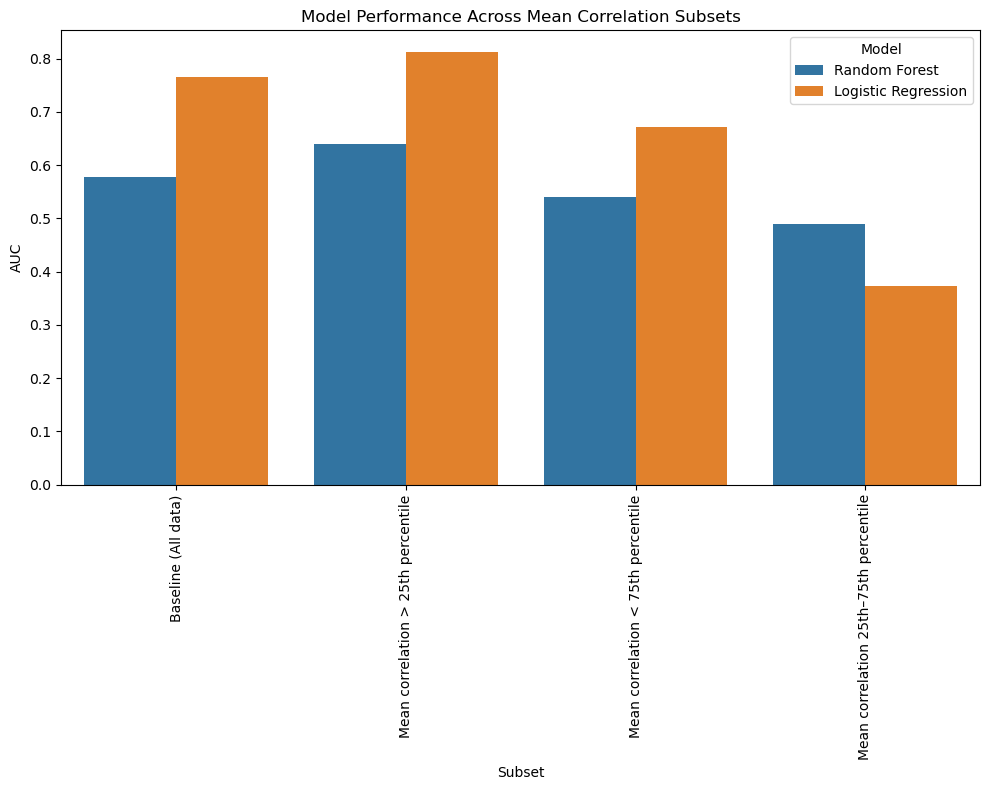

In [104]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=results_dataset1_df,
    x="Subset",
    y="AUC",
    hue="Model"
)

plt.title("Model Performance Across Mean Correlation Subsets")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [105]:
# Create a copy to avoid modifying original data
results_with_delta_dataset1 = results_dataset1_df.copy()

# Map baseline to each row
results_with_delta_dataset1["Baseline_AUC"] = results_with_delta_dataset1["Model"].map(baseline_map)

# Compute metrics
results_with_delta_dataset1["Delta_AUC"] = (
    results_with_delta_dataset1["AUC"] - results_with_delta_dataset1["Baseline_AUC"]
)

results_with_delta_dataset1["Percent_Improvement"] = (
    results_with_delta_dataset1["Delta_AUC"] / results_with_delta_dataset1["Baseline_AUC"] * 100
)

In [106]:
results_with_delta_dataset1

,Model,Subset,AUC,Num_rows,Dataset,Baseline_AUC,Delta_AUC,Percent_Improvement
0,Random Forest,Baseline (All data),0.578125,198,dataset1,0.578125,0.000000,0.000000
1,Random Forest,Mean correlation > 25th percentile,0.639200,148,dataset1,0.578125,0.061075,10.564324
2,Random Forest,Mean correlation < 75th percentile,0.539700,148,dataset1,0.578125,-0.038425,-6.646486
3,Random Forest,Mean correlation 25th–75th percentile,0.490200,98,dataset1,0.578125,-0.087925,-15.208649
4,Logistic Regression,Baseline (All data),0.765625,198,dataset1,0.765625,0.000000,0.000000
5,Logistic Regression,Mean correlation > 25th percentile,0.812500,148,dataset1,0.765625,0.046875,6.122449
6,Logistic Regression,Mean correlation < 75th percentile,0.672000,148,dataset1,0.765625,-0.093625,-12.228571
7,Logistic Regression,Mean correlation 25th–75th percentile,0.372500,98,dataset1,0.765625,-0.393125,-51.346939


In [107]:
plot_df_dataset1 = results_with_delta_dataset1[
    results_with_delta_dataset1["Subset"] != "Baseline (All data)"
]

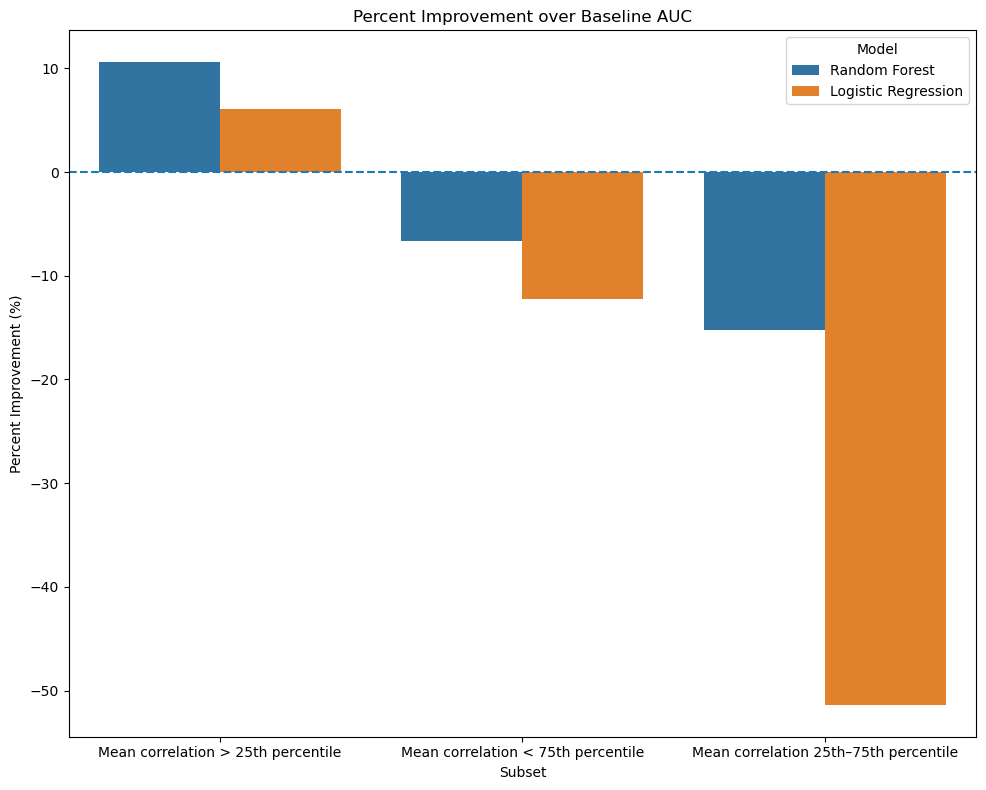

In [108]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=plot_df_dataset1,
    x="Subset",
    y="Percent_Improvement",
    hue="Model"
)

plt.axhline(0, linestyle="--")  # reference line
plt.title("Percent Improvement over Baseline AUC")
plt.ylabel("Percent Improvement (%)")
# plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [109]:
results_with_delta_dataset1.to_csv("results/results_with_delta_dataset1.csv", index = False)